In [1]:
!git clone https://github.com/issarmank/cs-4452-final-project.git

Cloning into 'cs-4452-final-project'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 86 (delta 41), reused 62 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 22.33 MiB | 11.75 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [2]:
import os
os.chdir("/content/cs-4452-final-project")
!git fetch --all

Fetching origin
Branch 'ahalane' set up to track remote branch 'ahalane' from 'origin'.
Switched to a new branch 'ahalane'


In [29]:
!git pull

Updating e0519ae..e004ec4
Fast-forward
 bayesianoptimizationresults.csv | 30 ++++++++++++++++++++++++++++++
 main.py                         | 12 ++++++------
 test_hpo.py                     | 12 ++++++------
 3 files changed, 42 insertions(+), 12 deletions(-)
 create mode 100644 bayesianoptimizationresults.csv


In [13]:
#!python main.py

-----------Epoch 1/3-----------
Train Loss: 0.8542 | Test Loss:  0.3484 | Test Accuracy: 90.45%
-----------Epoch 2/3-----------
Train Loss: 0.3146 | Test Loss:  0.2693 | Test Accuracy: 92.31%
-----------Epoch 3/3-----------
Train Loss: 0.2600 | Test Loss:  0.2318 | Test Accuracy: 93.39%
Training completed in 34.61 seconds.
Test Loss: 0.2318 | Test Accuracy:  93.39%
-----------Epoch 1/3-----------
Train Loss: 1.2769 | Test Loss:  0.6592 | Test Accuracy: 86.25%
-----------Epoch 2/3-----------
Train Loss: 0.5356 | Test Loss:  0.4275 | Test Accuracy: 89.36%
-----------Epoch 3/3-----------
Train Loss: 0.4045 | Test Loss:  0.3562 | Test Accuracy: 90.53%
Training completed in 30.00 seconds.
Test Loss: 0.3562 | Test Accuracy:  90.53%
-----------Epoch 1/3-----------
Train Loss: 0.3709 | Test Loss:  0.2220 | Test Accuracy: 94.06%
-----------Epoch 2/3-----------
Train Loss: 0.2323 | Test Loss:  0.2595 | Test Accuracy: 93.51%
-----------Epoch 3/3-----------
Train Loss: 0.2079 | Test Loss:  0.2021 

# Successive Halving for Hyperparameter Optimization

---

## 1. Goal

- Efficiently allocate resources (e.g., training time, epochs) to evaluate a large number of hyperparameter configurations.
- Focus computational effort on the most promising configurations.

---

## 2. Concept

1. Start with a large set of candidate hyperparameter configurations.
2. Evaluate each candidate with a **small budget** (e.g., fewer epochs, smaller subset of data).  
3. Rank candidates based on performance (accuracy, loss, or other metric).  
4. Keep the top fraction $\gamma$ of candidates for the next round.
5. **Increase the budget** for the surviving candidates (e.g., more epochs).  
6. Repeat until:
   - Only one candidate remains, or
   - A maximum budget is reached.

---

## 3. Notation

- $N$: initial number of candidate configurations  
- $B$: total resource budget (e.g., max epochs × number of candidates)  
- $r$: initial budget per candidate  
- $\eta$: downsampling rate (fraction of candidates to keep each round)  
- $s$: stage index (0 = first round)

---

## 4. Stage Computation

For stage $s$, define:

$$
n_s = \left\lfloor \frac{N}{\eta^s} \right\rfloor \quad \text{(number of candidates to evaluate)}
$$

$$
r_s = r \cdot \eta^s \quad \text{(budget per candidate at stage $s$)}
$$

- Evaluate $n_s$ candidates using $r_s$ resources each.
- Keep the top $\frac{n_s}{\eta}$ candidates for the next stage.

# Bayesian Optimization for Hyperparameter Tuning

---

## 1. Gaussian Process Kernel

$$
k(x_i, x_j) = \sigma_f^2 \exp\Bigg(-\frac{1}{2} \sum_{d=1}^D \frac{(x_{i,d} - x_{j,d})^2}{l_d^2}\Bigg)
$$

- $\sigma_f^2$: signal variance  
- $l_d$: length scale for dimension $d$  
- $D$: number of hyperparameters  

---

## 2. Kernel Matrix \(K\) for Existing Candidates

$$
K_{ij} = k(x_i, x_j) + \epsilon I
$$

- $\epsilon$ ensures invertibility  

---

## 3. Kernel Vector \(k_*\) for a New Candidate

$$
k_* =
\begin{bmatrix}
k(x_*, x_1) \\
\vdots \\
k(x_*, x_n)
\end{bmatrix}
$$

---

## 4. Posterior Predictive Mean

$$
\mu(x_*) = k_*^T K^{-1} Y
$$

- $Y$ stores negative accuracy (for minimization)  

---

## 5. Posterior Predictive Variance

$$
\sigma^2(x_*) = k(x_*, x_*) - k_*^T K^{-1} k_*
$$

---

## 6. Expected Improvement (EI)

$$
Z = \frac{y_{\min} - \mu(x_*)}{\sigma(x_*)}
$$

$$
EI(x_*) = \sigma(x_*) \Big[ Z \Phi(Z) + \phi(Z) \Big]
$$

- $\Phi$: CDF of standard normal  
- $\phi$: PDF of standard normal  

---

## 7. Selecting the Next Candidate

1. Generate multiple random candidate hyperparameter sets $x_*$  
2. Compute EI for each candidate  
3. Select the candidate with the highest EI  

---

## 8. Evaluate Candidate and Update Data

1. Evaluate $f(x_{\text{next}})$ → accuracy  
2. Append $x_{\text{next}}$ to candidates and $-f(x_{\text{next}})$ to $Y$  
3. Update Gaussian Process with new data for the next iteration  

---

## Summary: Steps in Bayesian Optimization for HPO

1. Start with a baseline set of random evaluations  
2. For a number of iterations:  
   - Compute $K$ and $k_*$  
   - Compute posterior mean $\mu(x_*)$ and variance $\sigma^2(x_*)$  
   - Compute EI for candidates  
   - Pick candidate with max EI, evaluate, update $Y$ and candidates  
3. Return best hyperparameter configuration based on performance

### Performance Distribution plot for Grid search



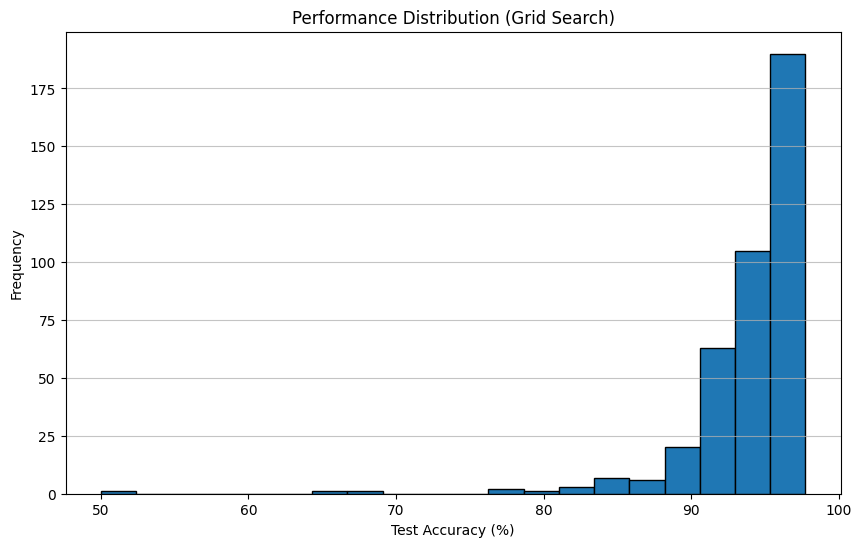

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV assuming the Google Colab path
csv_path = '/content/cs-4452-final-project/gridsearchresults.csv'
data = pd.read_csv(csv_path, header=None)

# Column 4 contains performance (test accuracy)
performance = data.iloc[:, 4]

# Plot distribution
plt.figure(figsize=(10,6))
plt.hist(performance, bins=20, edgecolor='black')
plt.title('Performance Distribution (Grid Search)')
plt.xlabel('Test Accuracy (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## **Performance Distribution plot for Grid Search 90-98% Accuracy**

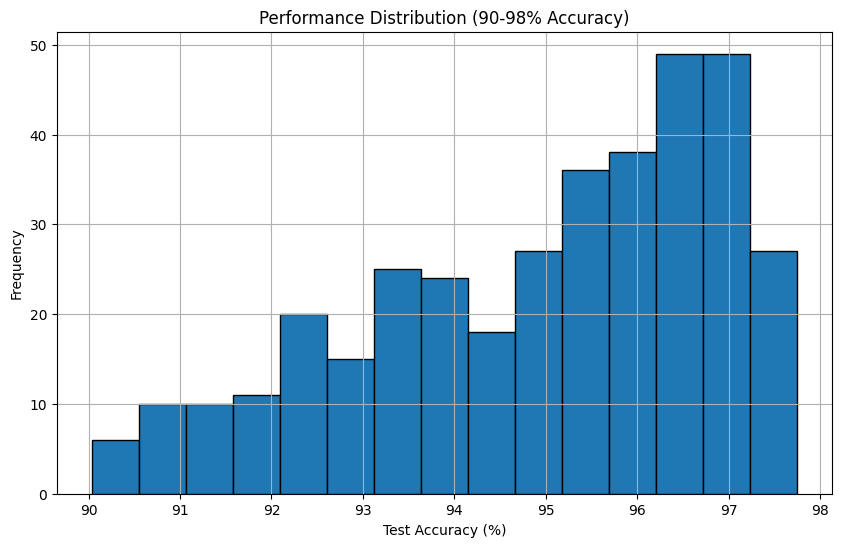

In [24]:
# Load CSV (assuming same structure as before)
data = np.loadtxt('/content/cs-4452-final-project/gridsearchresults.csv', delimiter=',')

# Filter for performance between 90 and 98
performance = data[:, 4]
performance_filtered = performance[(performance >= 90) & (performance <= 98)]

# Plot
plt.figure(figsize=(10,6))
plt.hist(performance_filtered, bins=15, edgecolor='black')
plt.title('Performance Distribution (90-98% Accuracy)')
plt.xlabel('Test Accuracy (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## **Performance vs Efficiency plot for Grid Search**

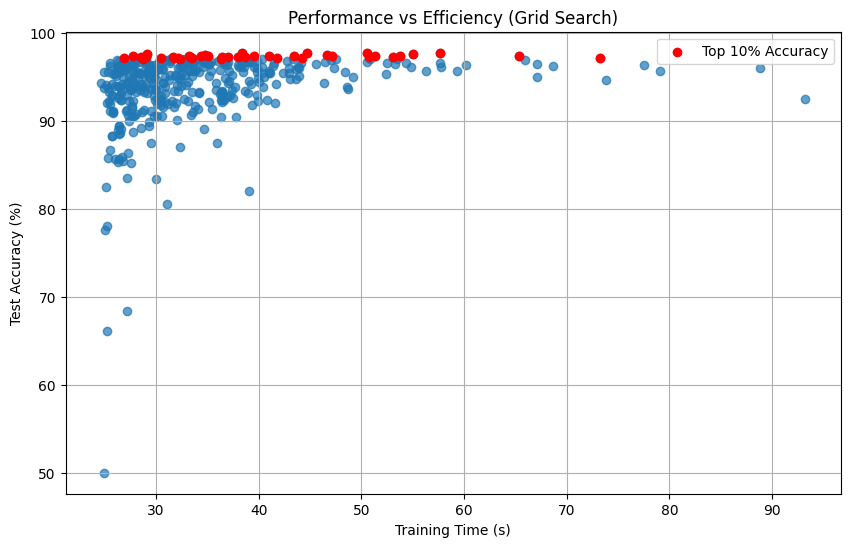

In [23]:

# Load CSV (assume same structure as your grid search)
data = np.loadtxt('/content/cs-4452-final-project/gridsearchresults.csv', delimiter=',')

performance = data[:, 4]   # Test Accuracy (%)
time_per_config = data[:, 5]  # Time in seconds

plt.figure(figsize=(10,6))
plt.scatter(time_per_config, performance, alpha=0.7)
plt.xlabel("Training Time (s)")
plt.ylabel("Test Accuracy (%)")
plt.title("Performance vs Efficiency (Grid Search)")
plt.grid(True)

# Optionally highlight top 10% accuracy points
top_mask = performance >= np.percentile(performance, 90)
plt.scatter(time_per_config[top_mask], performance[top_mask], color='red', label='Top 10% Accuracy')

plt.legend()
plt.show()

### **Performance Distribution plot for Random Search**


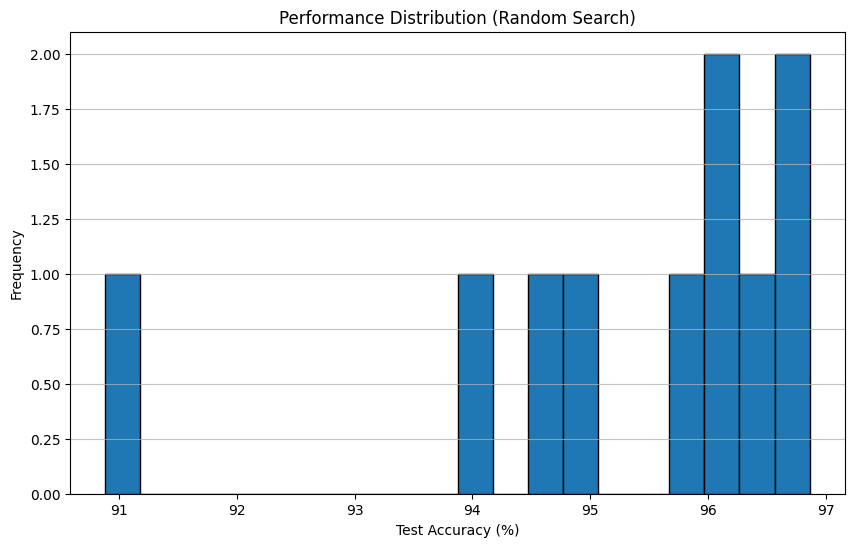

In [22]:
# Load CSV assuming the Google Colab path
csv_path = '/content/cs-4452-final-project/randomsearchresults.csv'
data = pd.read_csv(csv_path, header=None)

# Column 4 contains performance (test accuracy)
performance = data.iloc[:, 4]

# Plot distribution
plt.figure(figsize=(10,6))
plt.hist(performance, bins=20, edgecolor='black')
plt.title('Performance Distribution (Random Search)')
plt.xlabel('Test Accuracy (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Performance Distribution plot for Successive Halving

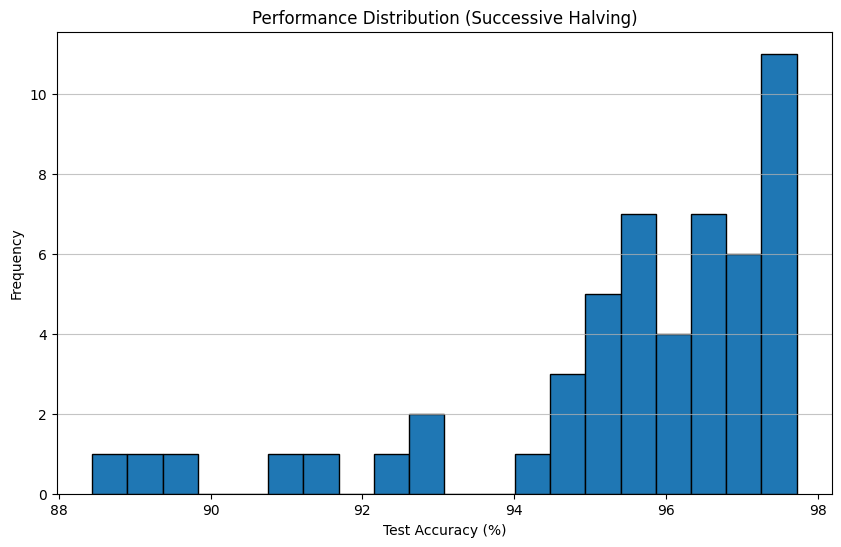

In [21]:
# Load CSV assuming the Google Colab path
csv_path = '/content/cs-4452-final-project/successivehalvingresults.csv'
data = pd.read_csv(csv_path, header=None)

# Column 4 contains performance (test accuracy)
performance = data.iloc[:, 4]

# Plot distribution
plt.figure(figsize=(10,6))
plt.hist(performance, bins=20, edgecolor='black')
plt.title('Performance Distribution (Successive Halving)')
plt.xlabel('Test Accuracy (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

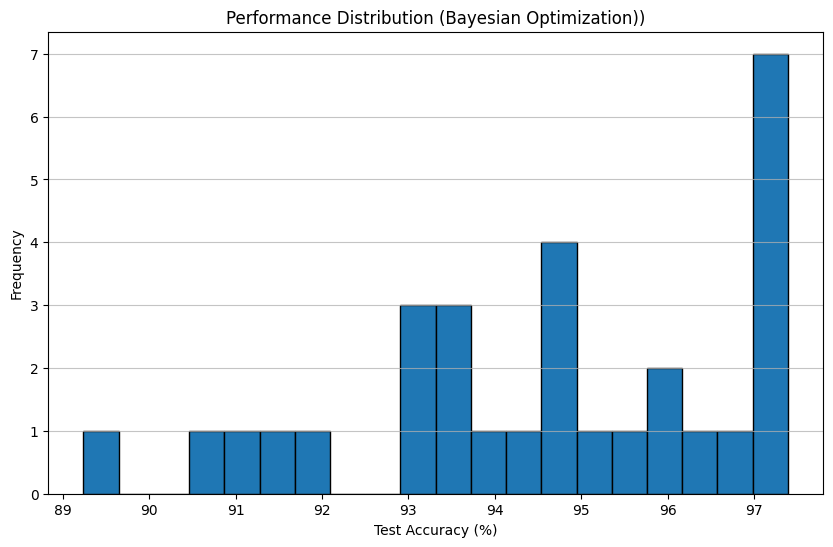

In [20]:
# Load CSV assuming the Google Colab path
csv_path = '/content/cs-4452-final-project/baysesianoptimizationresults.csv'
data = pd.read_csv(csv_path, header=None)

# Column 4 contains performance (test accuracy)
performance = data.iloc[:, 4]

# Plot distribution
plt.figure(figsize=(10,6))
plt.hist(performance, bins=20, edgecolor='black')
plt.title('Performance Distribution (Bayesian Optimization))')
plt.xlabel('Test Accuracy (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## **HPO using Grid Search complete...**

Total time taken: 13863.1623 seconds

The best test accuracy found was 97.74%

The configuration that performed the best was :

lr = 0.001

Number of hidden layers = 2

Dimension of hidden layers = 128

Batch Size = 32


## **HPO using Random Search complete...**

This algorithm took 329.2034 seconds

The best test accuracy found was 96.87%

The configuration that performed the best was :

lr = 0.0005

Number of hidden layers = 2

Dimension of hidden layers = 256

Batch Size = 64


## **HPO using Successive Halving complete...**

Total time: 2385.5794 s

Best test accuracy: 97.72%

Best configuration:

lr = 0.0005

Number of hidden layers = 3

Dimension of hidden layers = 256

Batch Size = 32


## **HPO using BayesianOptimization complete...**

Total time taken: 1182.0271 seconds

The best test accuracy found was 97.39%

The configuration that performed the best was :

lr = 0.0005

Number of hidden layers = 3.0

Dimension of hidden layers = 256.0

Batch Size = 64.0
